# Домашнее задание №5: Кластеризация данных о физической активности


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, MiniBatchKMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer

SEED = 42
np.random.seed(SEED)

N_CLUSTERS = 13


In [2]:
import kagglehub

path = kagglehub.competition_download('clustering-physical-activity-data')
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, 'Physical_Activity_Monitoring_unlabeled.csv'))
print('Shape:', df.shape)
df.head()

100%|██████████| 103M/103M [00:03<00:00, 30.1MB/s] 

Extracting files...


['Physical_Activity_Monitoring_unlabeled.csv']
Shape: (534601, 53)


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


## EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  ha

Признаки с пропусками:
handTemperature      0.007559
handAcc16_2          0.007559
handAcc16_1          0.007559
handAcc16_3          0.007559
handAcc6_1           0.007559
handMagne3           0.007559
handAcc6_2           0.007559
handAcc6_3           0.007559
handGyro1            0.007559
handGyro2            0.007559
handGyro3            0.007559
handMagne1           0.007559
handMagne2           0.007559
handOrientation4     0.007559
handOrientation1     0.007559
handOrientation2     0.007559
handOrientation3     0.007559
ankleOrientation2    0.004762
ankleOrientation3    0.004762
ankleTemperature     0.004762
ankleAcc16_1         0.004762
ankleOrientation4    0.004762
ankleGyro2           0.004762
ankleGyro1           0.004762
ankleAcc6_3          0.004762
ankleOrientation1    0.004762
ankleMagne3          0.004762
ankleMagne2          0.004762
ankleMagne1          0.004762
ankleGyro3           0.004762
ankleAcc6_1          0.004762
ankleAcc16_3         0.004762
ankleAcc16_2     

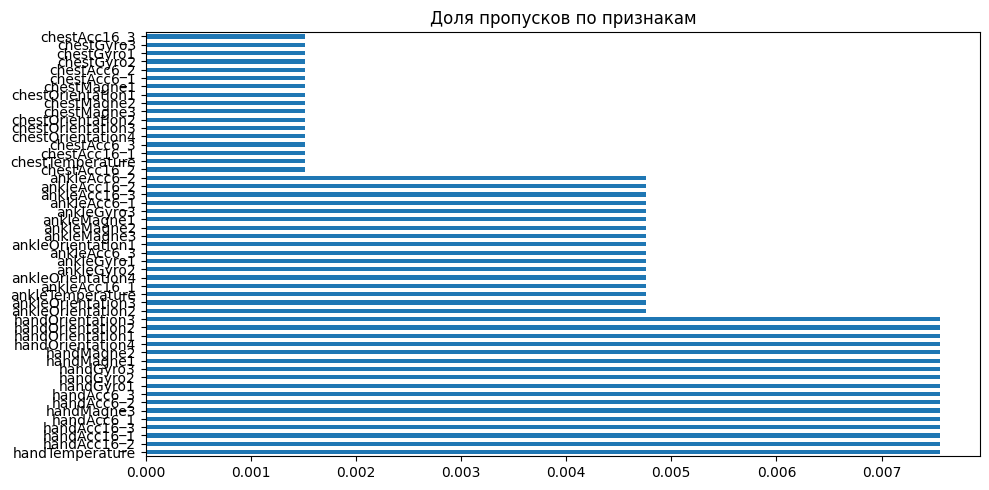

In [4]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print('Признаки с пропусками:')
print(missing)

plt.figure(figsize=(10, 5))
missing.plot(kind='barh')
plt.title('Доля пропусков по признакам')
plt.tight_layout()
plt.show()

Субъекты:
subject_id
5    76793
8    73047
6    70240
1    69882
2    68740
4    63740
7    62115
3    50044
Name: count, dtype: int64


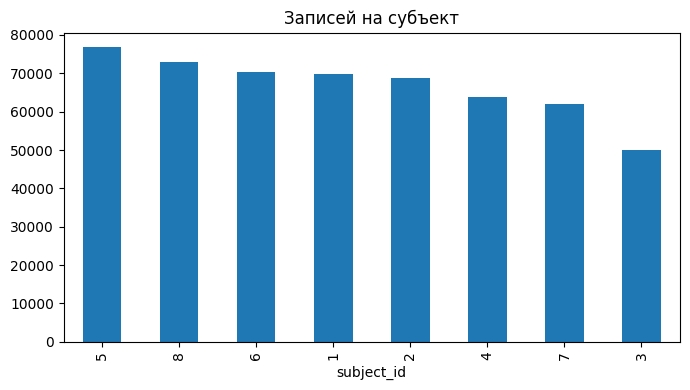

In [5]:
print('Субъекты:')
print(df['subject_id'].value_counts())

df['subject_id'].value_counts().plot(kind='bar', figsize=(7, 4), title='Записей на субъект')
plt.tight_layout()
plt.show()

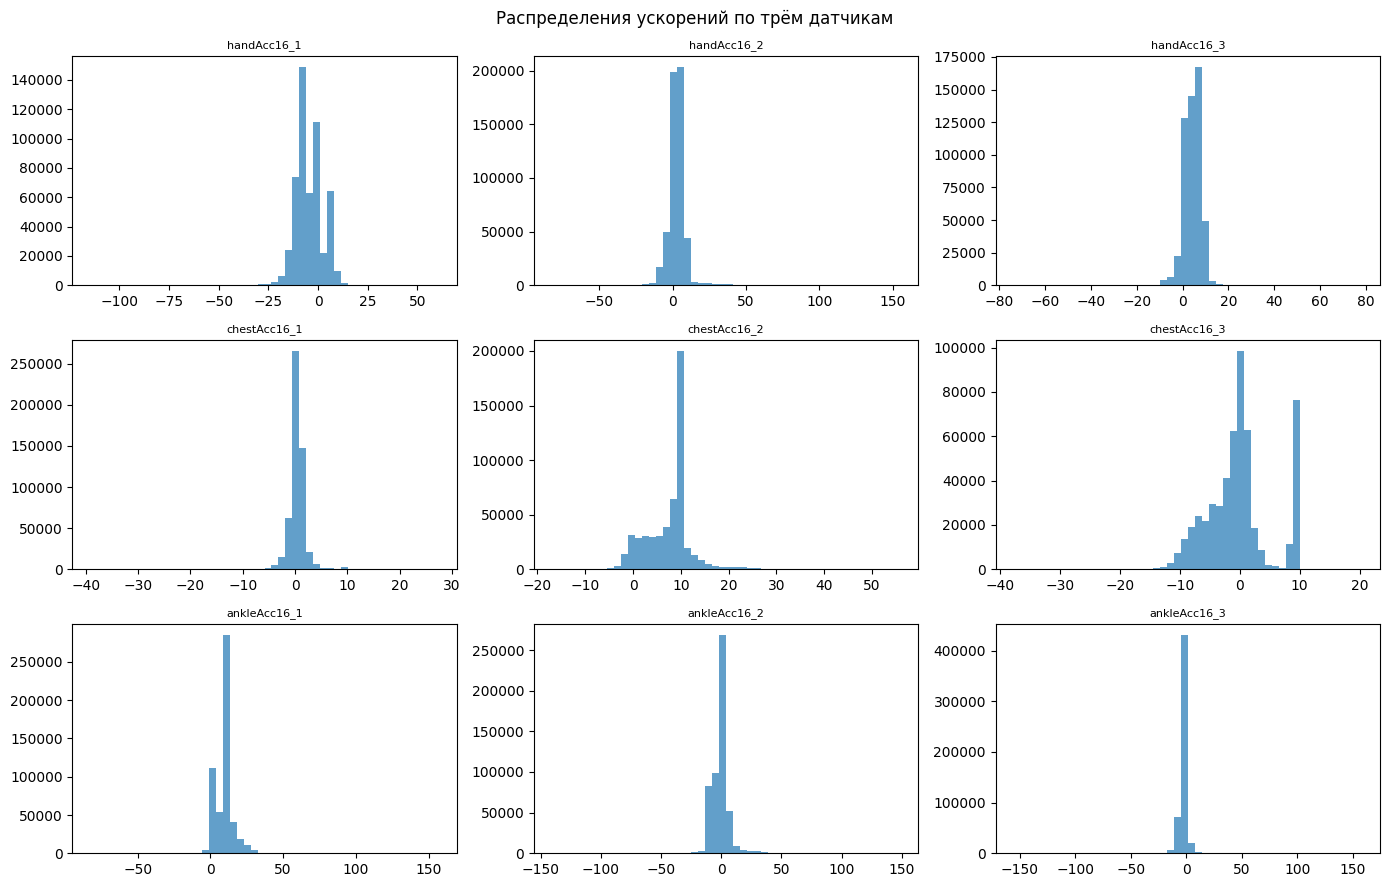

In [6]:
key_cols = ['handAcc16_1', 'handAcc16_2', 'handAcc16_3',
            'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3',
            'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3']

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    axes[i].hist(df[col].dropna(), bins=50, alpha=0.7)
    axes[i].set_title(col, fontsize=8)

plt.suptitle('Распределения ускорений по трём датчикам')
plt.tight_layout()
plt.show()

**Вывод:** Датасет содержит 534601 строк и 53 признака. Данные собраны с трёх IMU-датчиков (рука, грудь, лодыжка) от 8 субъектов. Пропуски есть примерно в 0.7% строк и равномерно распределены по сенсорным признакам. timestamp и subject_id не несут смысла для кластеризации и будут удалены.

## Предобработка

In [7]:
DROP_COLS = ['timestamp', 'subject_id']
X = df.drop(columns=DROP_COLS)

print('Признаков для кластеризации:', X.shape[1])
print(X.columns.tolist())

Признаков для кластеризации: 51
['handTemperature', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1', 'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3', 'handOrientation1', 'handOrientation2', 'handOrientation3', 'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3', 'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2', 'chestMagne3', 'chestOrientation1', 'chestOrientation2', 'chestOrientation3', 'chestOrientation4', 'ankleTemperature', 'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1', 'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3', 'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1', 'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4']


In [8]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

print('Пропуски после импутации:', np.isnan(X_imputed).sum())

Пропуски после импутации: 0


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print('Shape после стандартизации:', X_scaled.shape)

Shape после стандартизации: (534601, 51)


**Вывод:** Удалили timestamp и subject_id. Пропуски заполнили медианой. Стандартизировали данные, так как KMeans чувствителен к масштабу признаков.

## Feature Engineering — снижение размерности (PCA)

Компонент для 95% дисперсии: 32
Компонент для 99% дисперсии: 41


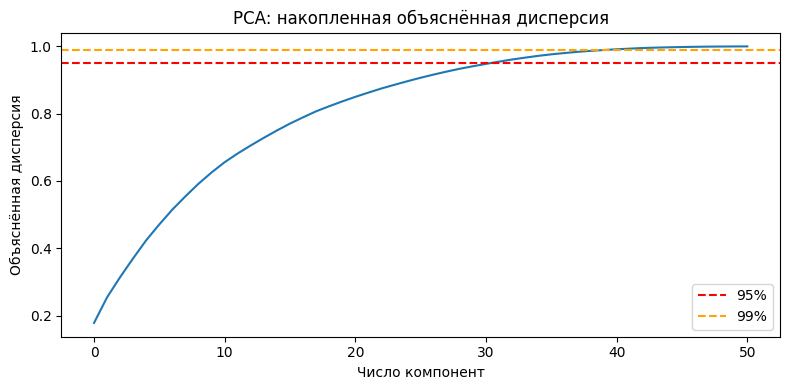

In [10]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1

print(f'Компонент для 95% дисперсии: {n_95}')
print(f'Компонент для 99% дисперсии: {n_99}')

plt.figure(figsize=(8, 4))
plt.plot(cumvar)
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.axhline(0.99, color='orange', linestyle='--', label='99%')
plt.xlabel('Число компонент')
plt.ylabel('Объяснённая дисперсия')
plt.title('PCA: накопленная объяснённая дисперсия')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
pca = PCA(n_components=n_95, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f'Shape после PCA: {X_pca.shape}')
print(f'Объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.3f}')

Shape после PCA: (534601, 32)
Объяснённая дисперсия: 0.955


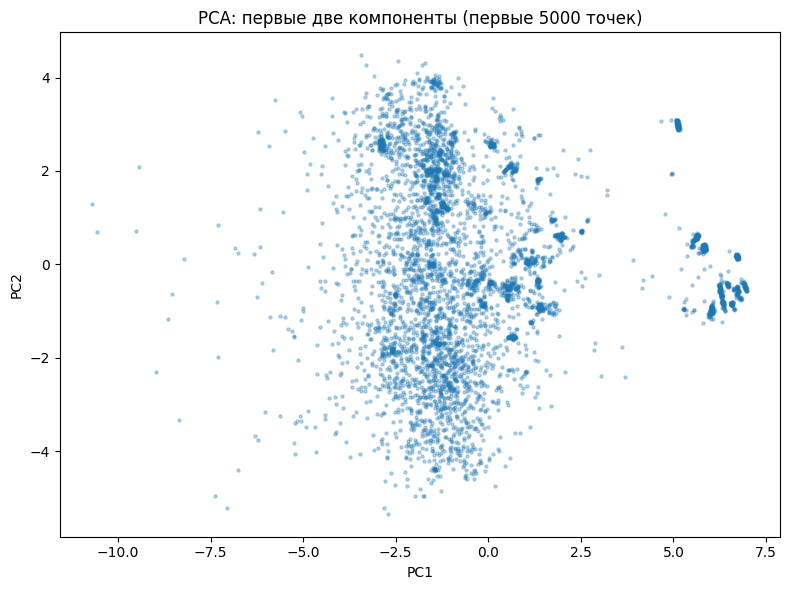

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:5000, 0], X_pca[:5000, 1], alpha=0.3, s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: первые две компоненты (первые 5000 точек)')
plt.tight_layout()
plt.show()

**Вывод:** PCA снижает размерность с 51 до 32 компонент и сохраняет 95% информации. Это ускоряет кластеризацию и снижает влияние шума в данных.

## Подбор числа кластеров

k=5: inertia=704123, silhouette=0.1531
k=6: inertia=679116, silhouette=0.1292
k=7: inertia=660169, silhouette=0.1563
k=8: inertia=636376, silhouette=0.1517
k=9: inertia=616438, silhouette=0.1515
k=10: inertia=594761, silhouette=0.1776
k=11: inertia=598949, silhouette=0.1373
k=12: inertia=579089, silhouette=0.1742
k=13: inertia=555219, silhouette=0.1730
k=14: inertia=556977, silhouette=0.1892
k=15: inertia=559604, silhouette=0.1234
k=16: inertia=528393, silhouette=0.1790
k=17: inertia=518078, silhouette=0.1830
k=18: inertia=516616, silhouette=0.1519
k=19: inertia=489823, silhouette=0.1981


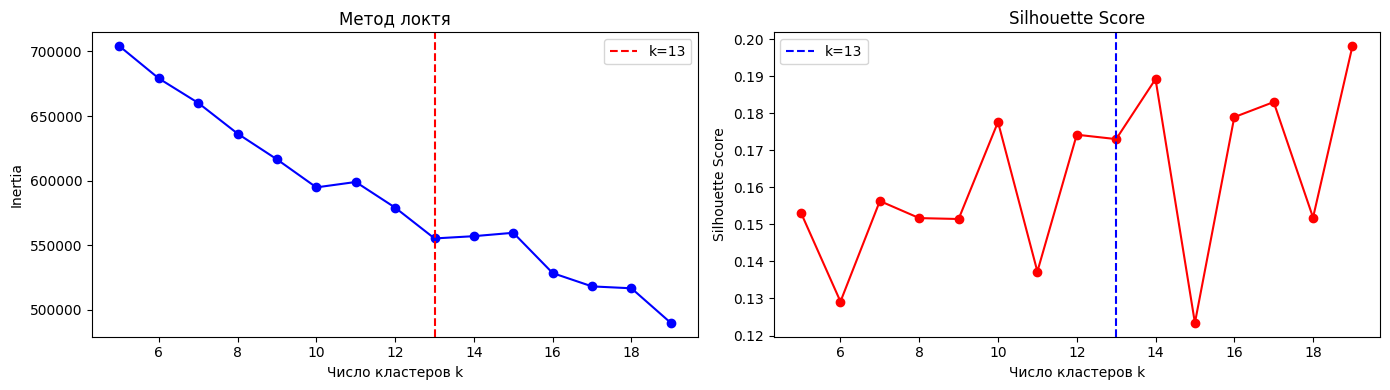

Лучший k по silhouette: 19


In [13]:
sample_idx = np.random.choice(len(X_pca), size=20000, replace=False)
X_sample = X_pca[sample_idx]

inertias = []
silhouettes = []
k_range = range(5, 20)

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=SEED, batch_size=5000, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=SEED)
    silhouettes.append(sil)
    print(f'k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set_xlabel('Число кластеров k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя')
axes[0].axvline(N_CLUSTERS, color='red', linestyle='--', label=f'k={N_CLUSTERS}')
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, 'ro-')
axes[1].set_xlabel('Число кластеров k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(N_CLUSTERS, color='blue', linestyle='--', label=f'k={N_CLUSTERS}')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'Лучший k по silhouette: {best_k}')


**Вывод:** Метод локтя не показывает явного изгиба, что типично для сенсорных данных с плавными переходами между активностями. По silhouette score максимум у k=19, но на Kaggle k=13 показал лучший результат (0.332 против 0.319 у k=18). Выбираем k=13.

## Обучение и сравнение моделей

In [14]:
results = []

km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
labels_km = km.fit_predict(X_sample)
sil_km = silhouette_score(X_sample, labels_km, sample_size=5000, random_state=SEED)
db_km = davies_bouldin_score(X_sample, labels_km)
ch_km = calinski_harabasz_score(X_sample, labels_km)
results.append({'model': 'KMeans', 'silhouette': sil_km, 'davies_bouldin': db_km, 'calinski_harabasz': ch_km})
print(f'KMeans: silhouette={sil_km:.4f}, DB={db_km:.4f}, CH={ch_km:.0f}')

mbkm = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=SEED, batch_size=5000, n_init=10)
labels_mbkm = mbkm.fit_predict(X_sample)
sil_mbkm = silhouette_score(X_sample, labels_mbkm, sample_size=5000, random_state=SEED)
db_mbkm = davies_bouldin_score(X_sample, labels_mbkm)
ch_mbkm = calinski_harabasz_score(X_sample, labels_mbkm)
results.append({'model': 'MiniBatchKMeans', 'silhouette': sil_mbkm, 'davies_bouldin': db_mbkm, 'calinski_harabasz': ch_mbkm})
print(f'MiniBatchKMeans: silhouette={sil_mbkm:.4f}, DB={db_mbkm:.4f}, CH={ch_mbkm:.0f}')

agg = AgglomerativeClustering(n_clusters=N_CLUSTERS)
labels_agg = agg.fit_predict(X_sample)
sil_agg = silhouette_score(X_sample, labels_agg, sample_size=5000, random_state=SEED)
db_agg = davies_bouldin_score(X_sample, labels_agg)
ch_agg = calinski_harabasz_score(X_sample, labels_agg)
results.append({'model': 'AgglomerativeClustering', 'silhouette': sil_agg, 'davies_bouldin': db_agg, 'calinski_harabasz': ch_agg})
print(f'AgglomerativeClustering: silhouette={sil_agg:.4f}, DB={db_agg:.4f}, CH={ch_agg:.0f}')

res_df = pd.DataFrame(results)
res_df


KMeans: silhouette=0.1814, DB=1.9306, CH=1301
MiniBatchKMeans: silhouette=0.1730, DB=2.2031, CH=1257
AgglomerativeClustering: silhouette=0.1554, DB=2.1297, CH=1169


,model,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,0.181385,1.930556,1301.151979
1,MiniBatchKMeans,0.173019,2.203111,1257.099434
2,AgglomerativeClustering,0.155376,2.129688,1168.768299


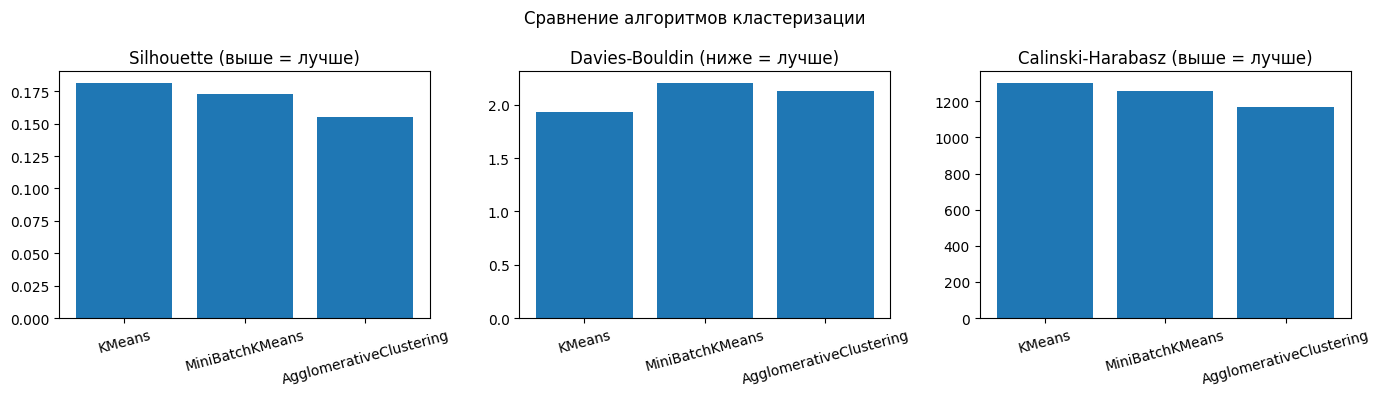

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(res_df['model'], res_df['silhouette'])
axes[0].set_title('Silhouette (выше = лучше)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(res_df['model'], res_df['davies_bouldin'])
axes[1].set_title('Davies-Bouldin (ниже = лучше)')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(res_df['model'], res_df['calinski_harabasz'])
axes[2].set_title('Calinski-Harabasz (выше = лучше)')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Сравнение алгоритмов кластеризации')
plt.tight_layout()
plt.show()

**Вывод:** KMeans лучший по silhouette и Calinski-Harabasz. AgglomerativeClustering уступает и работает медленнее. Для финального предсказания берём KMeans.

In [16]:
sample_small = X_pca[:10000]

for eps in [0.5, 1.0, 1.5, 2.0, 3.0]:
    db = DBSCAN(eps=eps, min_samples=50, n_jobs=-1)
    labels_db = db.fit_predict(sample_small)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = (labels_db == -1).sum()
    print(f'eps={eps}: кластеров={n_clusters}, шума={n_noise} ({n_noise/len(labels_db)*100:.1f}%)')


eps=0.5: кластеров=16, шума=7922 (79.2%)
eps=1.0: кластеров=24, шума=7045 (70.5%)
eps=1.5: кластеров=26, шума=6414 (64.1%)
eps=2.0: кластеров=23, шума=6027 (60.3%)
eps=3.0: кластеров=16, шума=5186 (51.9%)


**Вывод:** DBSCAN относит 50-80% данных к шуму при любых параметрах eps. Данные IMU не образуют плотных изолированных кластеров, поэтому DBSCAN для этой задачи не подходит.

## Подбор гиперпараметров (KMeans)

In [17]:
configs = [
    {'n_init': 5,  'init': 'k-means++'},
    {'n_init': 10, 'init': 'k-means++'},
    {'n_init': 20, 'init': 'k-means++'},
    {'n_init': 10, 'init': 'random'},
]

tuning_results = []
for cfg in configs:
    km_t = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, **cfg)
    labels_t = km_t.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_t, sample_size=5000, random_state=SEED)
    tuning_results.append({'config': str(cfg), 'silhouette': sil, 'inertia': km_t.inertia_})
    print(f"{cfg}: silhouette={sil:.4f}, inertia={km_t.inertia_:.0f}")

pd.DataFrame(tuning_results)

{'n_init': 5, 'init': 'k-means++'}: silhouette=0.1860, inertia=546498
{'n_init': 10, 'init': 'k-means++'}: silhouette=0.1814, inertia=546144
{'n_init': 20, 'init': 'k-means++'}: silhouette=0.1814, inertia=546144
{'n_init': 10, 'init': 'random'}: silhouette=0.1791, inertia=545844


,config,silhouette,inertia
0,"{'n_init': 5, 'init': 'k-means++'}",0.186041,546498.387626
1,"{'n_init': 10, 'init': 'k-means++'}",0.181385,546143.660383
2,"{'n_init': 20, 'init': 'k-means++'}",0.181385,546143.660383
3,"{'n_init': 10, 'init': 'random'}",0.179147,545844.171566


**Вывод:** k-means++ стабильно лучше random инициализации. n_init=10 даёт хороший результат без лишних затрат времени.

## Финальная модель и предсказание

In [18]:
print('Обучаем KMeans на полном датасете...')
final_model = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10, init='k-means++')
labels_full = final_model.fit_predict(X_pca)

print('Готово!')
print('Распределение по кластерам:')
print(pd.Series(labels_full).value_counts().sort_index())

Обучаем KMeans на полном датасете...
Готово!
Распределение по кластерам:
0      5448
1     65493
2     76008
3     12154
4     58737
5     76704
6     24138
7     10695
8     11572
9     50402
10    37646
11    58319
12    47285
Name: count, dtype: int64


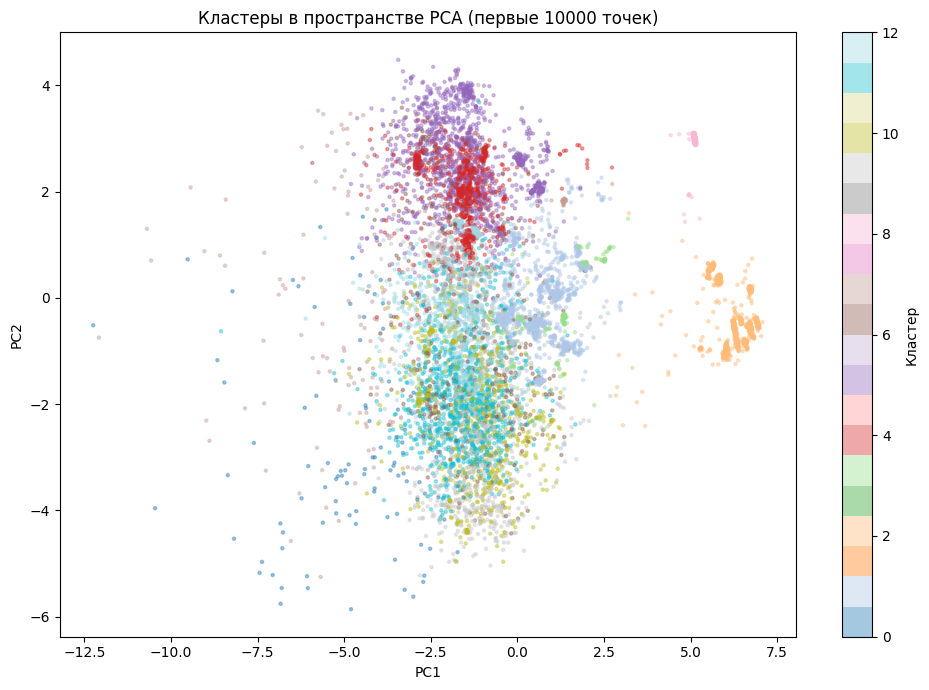

In [19]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:10000, 0], X_pca[:10000, 1],
    c=labels_full[:10000], cmap='tab20',
    alpha=0.4, s=5
)
plt.colorbar(scatter, label='Кластер')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Кластеры в пространстве PCA (первые 10000 точек)')
plt.tight_layout()
plt.show()

In [20]:
label_mapping = {}
new_label_counter = 1

new_labels = np.zeros(len(labels_full), dtype=int)
for i, label in enumerate(labels_full):
    if label not in label_mapping:
        label_mapping[label] = new_label_counter
        new_label_counter += 1
    new_labels[i] = label_mapping[label]

print('Маппинг кластеров:', label_mapping)
print('Уникальные метки после преобразования:', np.unique(new_labels))

Маппинг кластеров: {np.int32(2): 1, np.int32(9): 2, np.int32(5): 3, np.int32(1): 4, np.int32(4): 5, np.int32(11): 6, np.int32(10): 7, np.int32(12): 8, np.int32(3): 9, np.int32(6): 10, np.int32(0): 11, np.int32(8): 12, np.int32(7): 13}
Уникальные метки после преобразования: [ 1  2  3  4  5  6  7  8  9 10 11 12 13]


**Вывод:** Обучили KMeans с 13 кластерами на полном датасете после снижения размерности через PCA. Номера кластеров преобразованы в последовательный порядок согласно требованию задачи.

## Скриншот


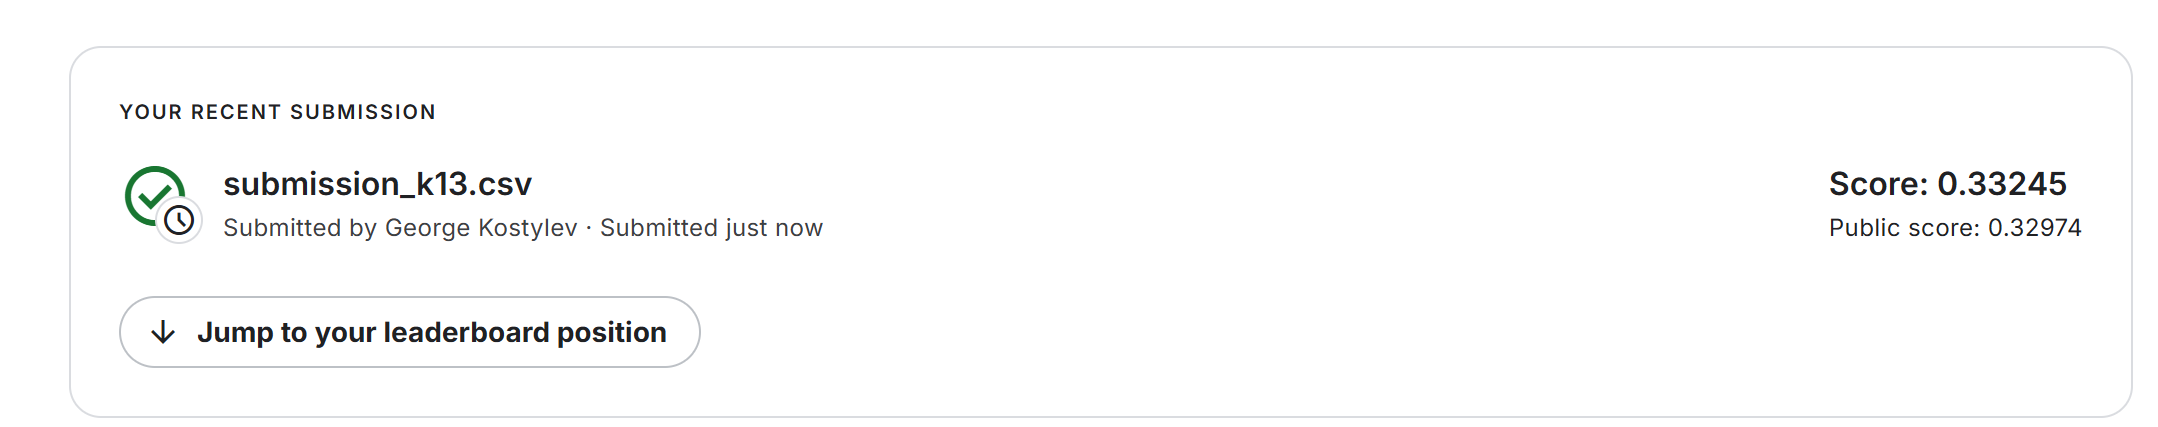